<a href="https://colab.research.google.com/github/aninda-p/aninda-p/blob/main/Aninda_GenAI_Assignment1_Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

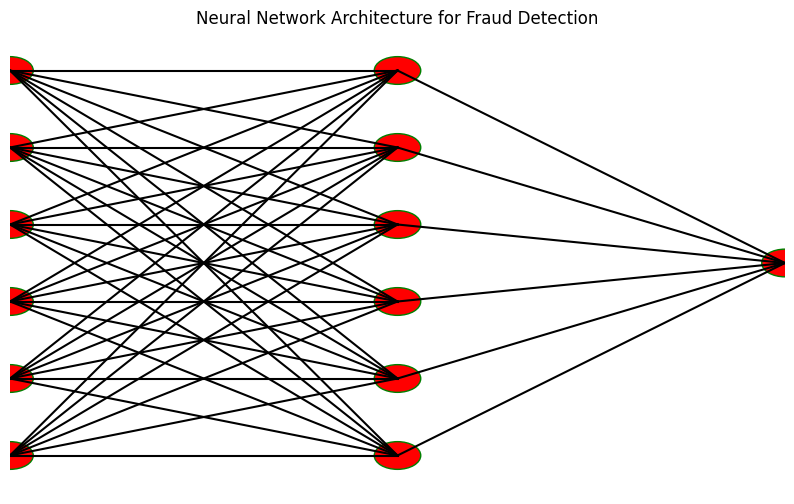

In [ ]:
# 2 Problem Statement

# Write a Python program to draw (visualize) the architecture of a Neural Network used to classify fraudulent and non-fraudulent credit card transactions.
# Assume the fraud detection dataset contains the following input features:
# Transaction Amount
# Transaction Time
# Merchant Category
# Customer Age
# Account Balance
# Number Of Transactions Today
# Fraud (0 = Genuine, 1 = Fraud)

# Lets generate a fraud dataset using make_classification.
from sklearn.datasets import make_classification
import pandas as pd

# Generate synthetic fraud dataset
X, y = make_classification(
    n_samples=500,
    # our input feature size [Transaction Amount,Transaction Time,Merchant Category,Customer Age,Account Balance,Number Of Transactions Today,Fraud]
    n_features=6,
    n_informative=4,
    n_redundant=0,
    random_state=42
)

df = pd.DataFrame(X, columns=[
    "Transaction Amount",
    "Transaction Time",
    "Merchant Category",
    "Customer Age",
    "Account Balance",
    "Transactions Today"
])

df["Fraud"] = y # output
df.head()

# creates a simple fraud‑detection neural network.
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(6,)),# 6 input features
    tf.keras.layers.Dense(6, activation='relu'), #hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid')                   # fraud / not fraud
])

model.summary()

#  for visualization
import matplotlib.pyplot as plt

#store number of neurons per layer
layer_sizes = []

# input size from the model itself
input_dim = model.input_shape[1] #model.input_shape (None, 6)
layer_sizes.append(input_dim) #extracts 6 input features

# read and Add Dense layer from model
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer_sizes.append(layer.units)

fig, ax = plt.subplots(figsize=(10, 6)) #create drawing canvas
ax.axis('off')
#spacing between neurons & layers
v_spacing = 1.0 / max(layer_sizes)#Vertical spacing
h_spacing = 1.0 / (len(layer_sizes) - 1)#Horizontal spacing

# draw each neurons
for i, layer_size in enumerate(layer_sizes):
    layer_top = v_spacing * (layer_size - 1) / 2 + 0.5
    for j in range(layer_size):
        circle = plt.Circle(
            (i * h_spacing, layer_top - j * v_spacing),
            0.03, color='red', ec='green'
        )
        ax.add_patch(circle)

# draw connections (a:  neurons in left layer, b: neurons in right layer)
for i, (a, b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
    layer_top_a = v_spacing * (a - 1) / 2 + 0.5
    layer_top_b = v_spacing * (b - 1) / 2 + 0.5
    #draw each connection lines
    for j in range(a):
        for k in range(b):
            line = plt.Line2D(
                [i * h_spacing, (i + 1) * h_spacing],
                [layer_top_a - j * v_spacing, layer_top_b - k * v_spacing],
                color='black'
            )
            ax.add_line(line)

plt.title("Neural Network Architecture for Fraud Detection")
plt.show()

